# Endogenous Reachability Collapse (ERC)
## A minimal model of recoverability under hypoxic timing constraints

This notebook presents a minimal dynamical system in which recoverability depends on the temporal structure of perturbation, not only on total load.

The notebook is organized in two parts:
1. a **demo regime** to visualize representative trajectories and matched-AUC effects
2. a **phase regime** to resolve the recoverability boundary more sharply


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 180

t = np.linspace(0, 200, 4000)
dt = t[1] - t[0]


## Model definition

`H(t)` is the hypoxic input, `C(t)` is an internal accumulated constraint, and `X(t)` is the functional capacity variable.

Recovery is suppressed by internal constraint through an exponential factor, while damage increases with both the external perturbation and the accumulated internal constraint.


In [18]:
def make_hypoxia_pulse(t, t_start, duration, hypoxic_load):
    H = np.zeros_like(t)
    mask = (t >= t_start) & (t <= t_start + duration)
    H[mask] = hypoxic_load
    return H


def simulate_hrc_recovery(
    t,
    hypoxia_input,
    tau_C=50.0,
    alpha=2.2,
    beta=0.12,
    k_repair=0.7,
    k_damage=1.2,
    x0=1.0
):
    C = np.zeros_like(t)
    X = np.zeros_like(t)
    X[0] = x0

    for i in range(1, len(t)):
        dC = alpha * hypoxia_input[i-1] - C[i-1] / tau_C

        repair = k_repair * (1.0 - X[i-1]) * np.exp(-beta * C[i-1])
        damage = k_damage * hypoxia_input[i-1] * (1.0 + 0.5 * C[i-1])

        dX = repair - damage

        C[i] = max(C[i-1] + dt * dC, 0.0)
        X[i] = X[i-1] + dt * dX
        X[i] = min(X[i], 1.05)

    return {
        "C": C,
        "X": X,
        "x_final": X[-1],
        "x_min": np.min(X),
        "late_x": np.mean(X[int(0.8 * len(X)):])
    }


def classify_recovery(out, threshold=0.8):
    return int(out["late_x"] >= threshold)


## Parameter sets

Two parameter regimes are used for clarity.

**Demo regime (Figures 1–2)**  
Used to illustrate representative trajectories and AUC effects.
- tau_C = 20.0
- alpha = 0.35
- beta = 0.08
- k_repair = 0.12
- k_damage = 0.06

**Phase regime (Figures 3–4)**  
Used to resolve the recoverability boundary more sharply.
- tau_C = 50.0
- alpha = 2.2
- beta = 0.12
- k_repair = 0.7
- k_damage = 1.2

This separation is used to improve visualization, not to change the underlying mechanism.


In [19]:
params_demo = dict(
    tau_C=20.0,
    alpha=0.35,
    beta=0.08,
    k_repair=0.12,
    k_damage=0.06,
    x0=1.0
)

params_phase = dict(
    tau_C=50.0,
    alpha=2.2,
    beta=0.12,
    k_repair=0.7,
    k_damage=1.2,
    x0=1.0
)


## Figure 1. Representative trajectories under matched hypoxic load

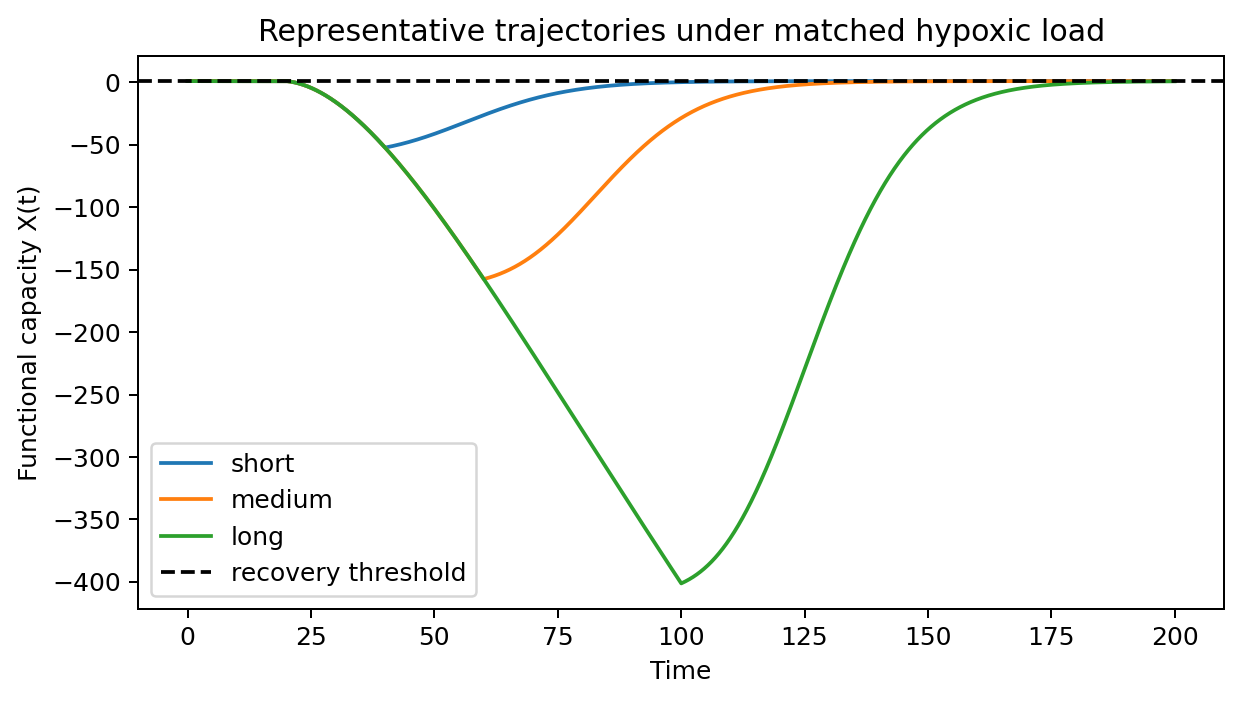

,case,duration,load,late_x,x_min,recovered
0,short,20,6,0.999842,-52.247186,1
1,medium,40,6,0.989820,-157.529137,1
2,long,80,6,-2.366567,-401.183421,0


In [20]:
cases = [
    ("short", 20, 6),
    ("medium", 40, 6),
    ("long", 80, 6),
]

summary_rows = []

plt.figure(figsize=(7, 4), dpi=180)

for label, duration, load in cases:
    H = make_hypoxia_pulse(t, 20, duration, load)
    out = simulate_hrc_recovery(t, H, **params_demo)

    summary_rows.append({
        "case": label,
        "duration": duration,
        "load": load,
        "late_x": out["late_x"],
        "x_min": out["x_min"],
        "recovered": classify_recovery(out)
    })

    plt.plot(t, out["X"], label=label)

plt.axhline(0.8, linestyle="--", color="black", label="recovery threshold")
plt.xlabel("Time")
plt.ylabel("Functional capacity X(t)")
plt.title("Representative trajectories under matched hypoxic load")
plt.legend()
plt.tight_layout()
plt.savefig("figure1_representative_trajectories.png", bbox_inches="tight")
plt.show()

rep_df = pd.DataFrame(summary_rows)
rep_df


## Mechanistic support: internal constraint dynamics

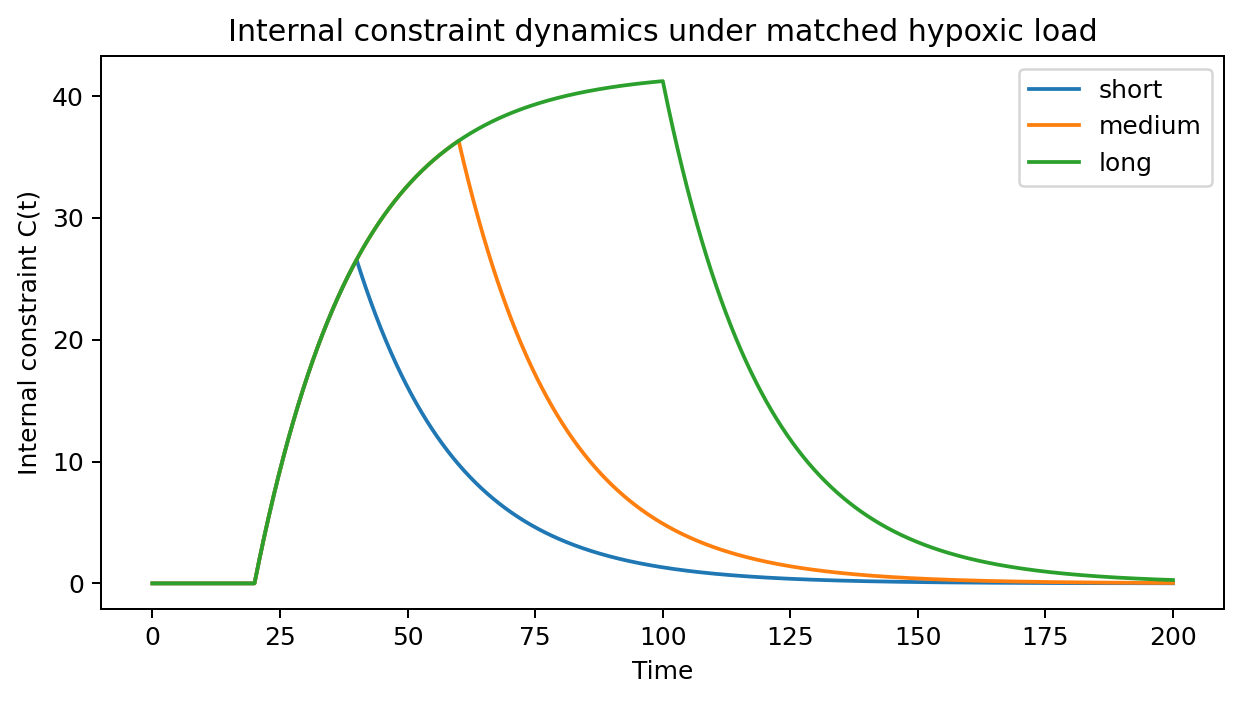

In [21]:
plt.figure(figsize=(7, 4), dpi=180)

for label, duration, load in cases:
    H = make_hypoxia_pulse(t, 20, duration, load)
    out = simulate_hrc_recovery(t, H, **params_demo)
    plt.plot(t, out["C"], label=label)

plt.xlabel("Time")
plt.ylabel("Internal constraint C(t)")
plt.title("Internal constraint dynamics under matched hypoxic load")
plt.legend()
plt.tight_layout()
plt.savefig("figure1b_internal_constraint.png", bbox_inches="tight")
plt.show()


## Figure 2. Recoverability under matched total load (AUC)

Here the total load is held constant while duration varies and load is adjusted as `AUC / duration`.


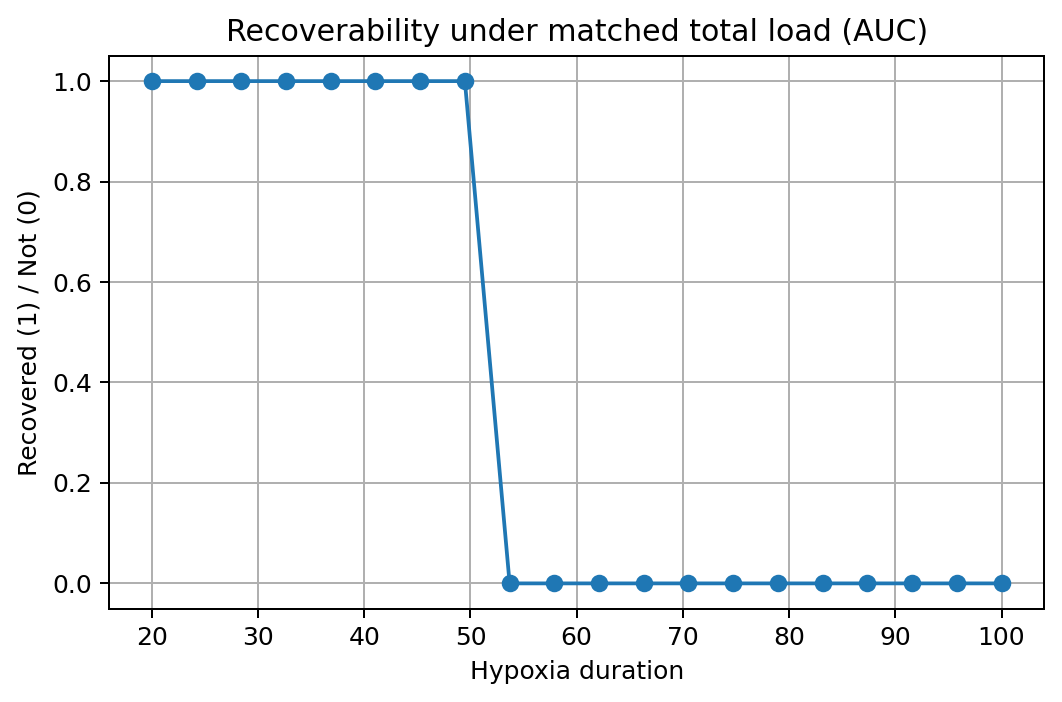

,duration,load,late_x,recovered
0,20.000000,20.000000,0.969636,1
1,24.210526,16.521739,0.961646,1
2,28.421053,14.074074,0.950591,1
3,32.631579,12.258065,0.936561,1
4,36.842105,10.857143,0.917924,1
5,41.052632,9.743590,0.893099,1
6,45.263158,8.837209,0.859954,1
7,49.473684,8.085106,0.814183,1
8,53.684211,7.450980,0.754460,0
9,57.894737,6.909091,0.674523,0


In [22]:
AUC = 400
durations_auc = np.linspace(20, 100, 20)

auc_rows = []

for duration in durations_auc:
    load = AUC / duration
    H = make_hypoxia_pulse(t, 20, duration, load)
    out = simulate_hrc_recovery(t, H, **params_demo)

    auc_rows.append({
        "duration": duration,
        "load": load,
        "late_x": out["late_x"],
        "recovered": classify_recovery(out)
    })

auc_df = pd.DataFrame(auc_rows)

plt.figure(figsize=(6, 4), dpi=180)
plt.plot(auc_df["duration"], auc_df["recovered"], marker="o")
plt.xlabel("Hypoxia duration")
plt.ylabel("Recovered (1) / Not (0)")
plt.title("Recoverability under matched total load (AUC)")
plt.grid(True)
plt.tight_layout()
plt.savefig("figure2_matched_auc.png", bbox_inches="tight")
plt.show()

auc_df


## Figure 3. Recoverability phase map (zoom on transition region)

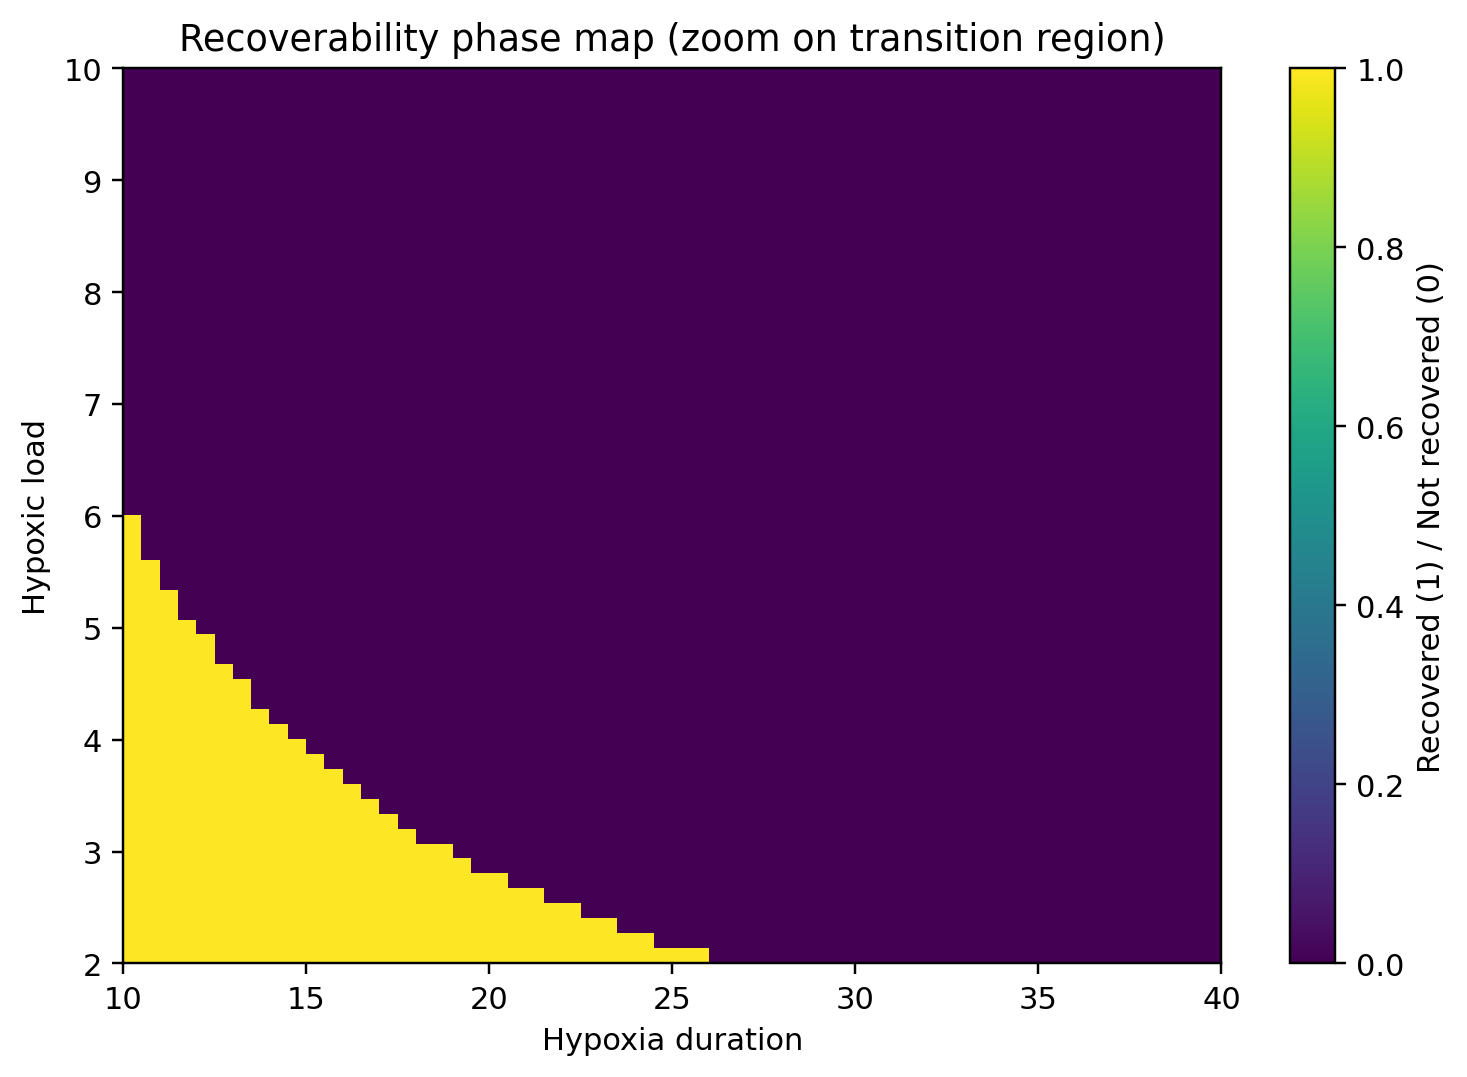

In [23]:
# --- Zoomed phase map (focus on transition region) ---

durations_zoom = np.linspace(10, 40, 60)
loads_zoom = np.linspace(2, 10, 60)

recover_map_zoom = np.zeros((len(loads_zoom), len(durations_zoom)))

for i, load in enumerate(loads_zoom):
    for j, duration in enumerate(durations_zoom):
        H = make_hypoxia_pulse(t, 20, duration, load)
        out = simulate_hrc_recovery(t, H, **params_phase)
        recover_map_zoom[i, j] = classify_recovery(out)

plt.figure(figsize=(7, 5), dpi=220)
plt.imshow(
    recover_map_zoom,
    origin="lower",
    aspect="auto",
    extent=[durations_zoom.min(), durations_zoom.max(),
            loads_zoom.min(), loads_zoom.max()],
    vmin=0,
    vmax=1,
)

plt.colorbar(label="Recovered (1) / Not recovered (0)")
plt.xlabel("Hypoxia duration")
plt.ylabel("Hypoxic load")
plt.title("Recoverability phase map (zoom on transition region)")

plt.tight_layout()
plt.show()

## Figure 4. Estimated recoverability boundary (zoom region)


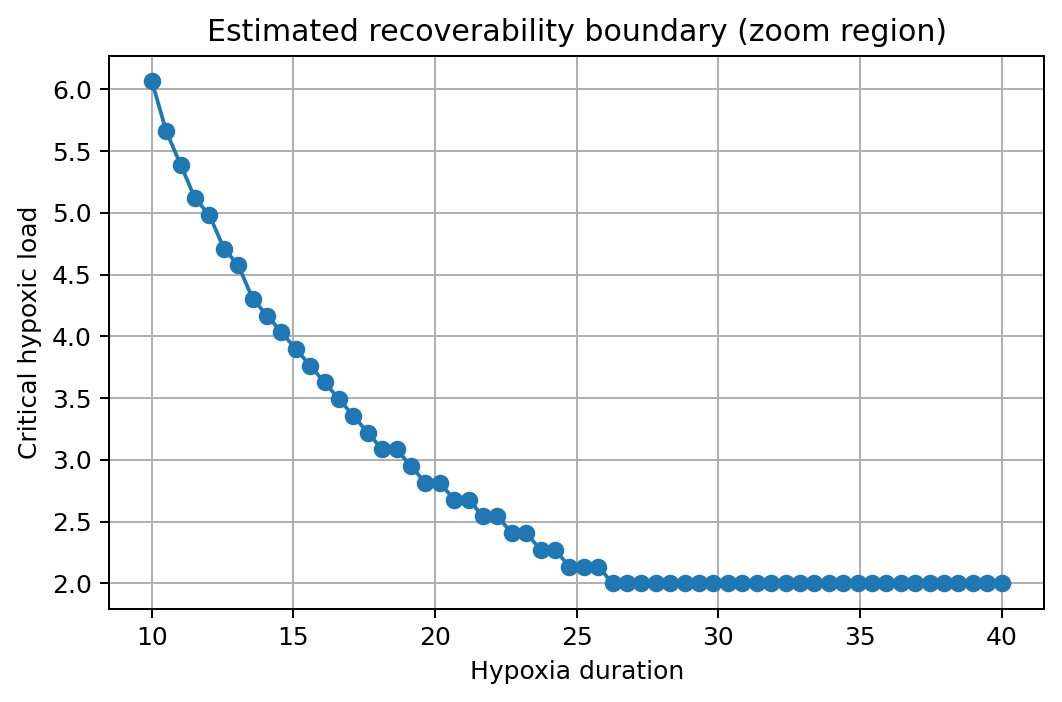

,duration,boundary_load
0,10.000000,6.067797
1,10.508475,5.661017
2,11.016949,5.389831
3,11.525424,5.118644
4,12.033898,4.983051
5,12.542373,4.711864
6,13.050847,4.576271
7,13.559322,4.305085
8,14.067797,4.169492
9,14.576271,4.033898


In [25]:
boundary_zoom_points = []

for j, duration in enumerate(durations_zoom):
    col = recover_map_zoom[:, j]
    idx_not = np.where(col == 0)[0]
    if len(idx_not) > 0:
        boundary_zoom_points.append((duration, loads_zoom[idx_not[0]]))

boundary_zoom_df = pd.DataFrame(boundary_zoom_points, columns=["duration", "boundary_load"])

plt.figure(figsize=(6, 4), dpi=180)
plt.plot(boundary_zoom_df["duration"], boundary_zoom_df["boundary_load"], marker="o")
plt.xlabel("Hypoxia duration")
plt.ylabel("Critical hypoxic load")
plt.title("Estimated recoverability boundary (zoom region)")
plt.grid(True)
plt.tight_layout()
plt.savefig("figure4_boundary_zoom.png", bbox_inches="tight")
plt.show()

boundary_zoom_df

## Control cases

A simple negative/positive control confirms that low load remains recoverable whereas high load does not.


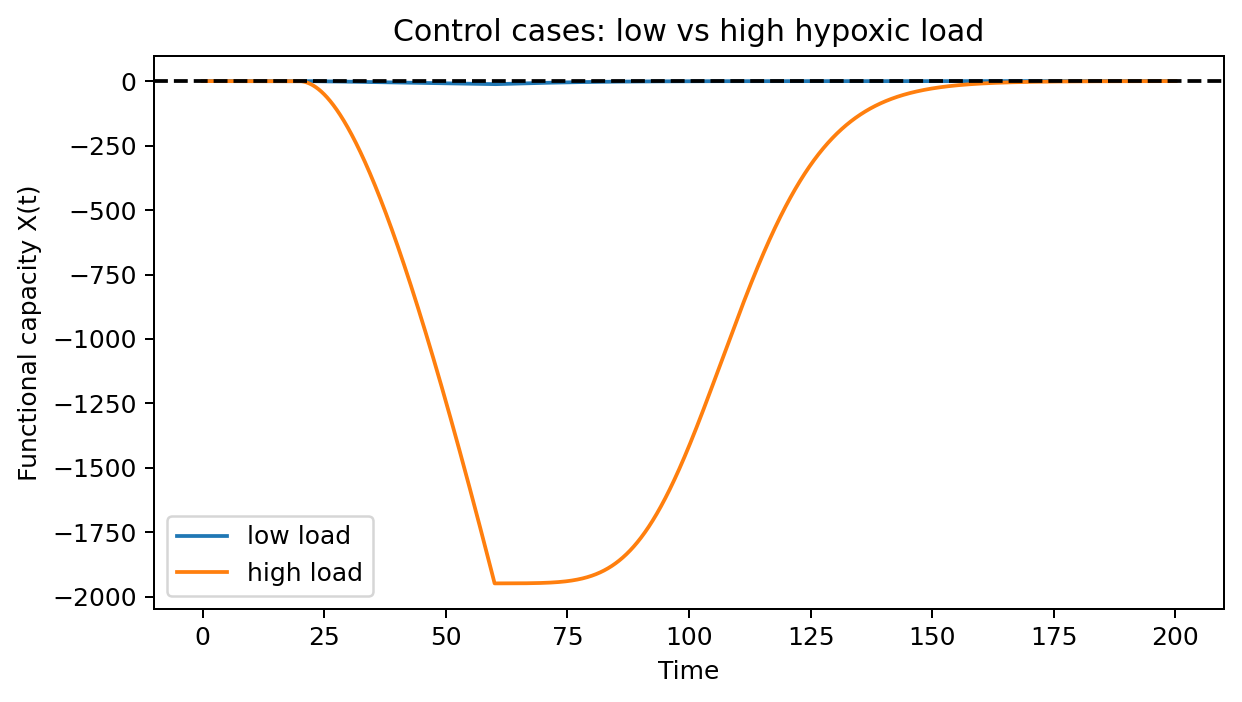

,case,duration,load,late_x,recovered
0,low load,40,2,0.999906,1
1,high load,40,20,-1.024734,0


In [26]:
control_cases = [
    ("low load", 40, 2),
    ("high load", 40, 20),
]

control_rows = []

plt.figure(figsize=(7, 4), dpi=180)

for label, duration, load in control_cases:
    H = make_hypoxia_pulse(t, 20, duration, load)
    out = simulate_hrc_recovery(t, H, **params_demo)

    control_rows.append({
        "case": label,
        "duration": duration,
        "load": load,
        "late_x": out["late_x"],
        "recovered": classify_recovery(out)
    })

    plt.plot(t, out["X"], label=label)

plt.axhline(0.8, linestyle="--", color="black")
plt.xlabel("Time")
plt.ylabel("Functional capacity X(t)")
plt.title("Control cases: low vs high hypoxic load")
plt.legend()
plt.tight_layout()
plt.savefig("control_low_vs_high_load.png", bbox_inches="tight")
plt.show()

control_df = pd.DataFrame(control_rows)
control_df


## Summary

This minimal model shows that recoverability depends on the temporal structure of perturbation.

Key observations:
- Systems may fail to recover without losing the underlying state space.
- A recoverability boundary emerges in the space of load and duration.
- Under matched total load (AUC), recovery depends on delivery time.
- Internal constraint accumulation limits access to recovery.

These results are consistent with the hypothesis of endogenous reachability collapse.


## Export results

In [27]:
rep_df.to_csv("representative_cases.csv", index=False)
auc_df.to_csv("auc_results.csv", index=False)
boundary_zoom_df.to_csv("boundary_curve_zoom.csv", index=False)
control_df.to_csv("control_cases.csv", index=False)
np.savetxt("phase_map_zoom_matrix.csv", recover_map_zoom, delimiter=",")

print("Export complete.")


Export complete.
